In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import tensorflow as tf

from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

from tensorflow.keras.regularizers import L2
from tensorflow.keras.layers import Lambda, Dense, Input, Dropout, Embedding, LSTM
from tensorflow.keras.models import Model


# Utils

In [64]:
def encode_objects(df):
    for col, dtype in df.dtypes.items():
        if dtype == 'object':
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
    return df

# Preprocessing

In [65]:
df_test = pd.read_csv("datasets/unsw-nb15/UNSW_NB15_testing-set.csv")
df_train = pd.read_csv("datasets/unsw-nb15/UNSW_NB15_training-set.csv")

In [66]:
# Keeping only the features selected in the paper A stacking... by Smitha Rajagopal

keep_cols = ['sbytes', 'sttl', 'sload', 'tcprtt', 'smean', 'ct_srv_src', 'ct_state_ttl', 'ct_src_dport_ltm', 'ct_dst_src_ltm', 'ct_srv_dst', 'service', 'label']

df_test = df_test[df_test.columns.intersection(keep_cols)]
df_train = df_train[df_train.columns.intersection(keep_cols)]

In [67]:
df_train['label'].value_counts()
df_test['label'].value_counts()

label
1    45332
0    37000
Name: count, dtype: int64

In [68]:
df_train_reduced = df_train.query('label == 0').sample(56000)

normal = df_test.query('label == 0').sample(37000)
attack = df_test.query('label == 1').sample(1000)
df_test_reduced = pd.concat([normal, attack]).sample(frac=1)

In [69]:
y_train = df_train_reduced['label']
x_train = df_train_reduced.drop("label", axis=1)

y_test = df_test_reduced['label']
x_test = df_test_reduced.drop("label", axis=1)

In [70]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [71]:
print(x_test.shape)
print(x_train.shape)

(38000, 11)
(44800, 11)


In [72]:
# encoding features which have data type as object and normalizing and normalizing numerical ones in specified interval

x_train = encode_objects(x_train)
x_val = encode_objects(x_val)
x_test = encode_objects(x_test)

In [73]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

## Tensorboard

In [74]:
# Load the extension and start TensorBoard
%load_ext tensorboard
%tensorboard --logdir logs/autoencoder_unsw/

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 20796), started 2 days, 0:06:55 ago. (Use '!kill 20796' to kill it.)

# Model

In [75]:
BATCH_SIZE = 32
EPOCHS = 100
input_dim = x_train_scaled.shape[1]
intermediate_dim = [8, 4]
latent_dim = 2

# encoder
inputs = Input(shape=(input_dim, ), name='encoder_input')
for index in range(len(intermediate_dim)):
    if index == 0:
        x = Dense(intermediate_dim[index], activation='relu')(inputs)
    else:
        x = Dense(intermediate_dim[index], activation='relu')(x)
z = Dense(latent_dim, activation='relu', name='z')(x)

encoder = Model(inputs, z, name='encoder')
encoder.summary()

# decoder
latent_inputs = Input(shape=(latent_dim, ), name='z_sampling')
for index in reversed(range(len(intermediate_dim))):
    if index == len(intermediate_dim) - 1:
        x = Dense(intermediate_dim[index], activation='relu')(latent_inputs)
    else:
        x = Dense(intermediate_dim[index], activation='relu')(x)
outputs = Dense(input_dim, activation='sigmoid')(x)

decoder = Model(latent_inputs, outputs, name='decoder')
decoder.summary()

outputs = decoder(encoder(inputs))
autoencoder = Model(inputs, outputs, name='autoencoder')

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ z (Dense)                       │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142 (568.00 B)

 Trainable params: 142 (568.00 B)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 11)             │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [76]:
autoencoder.compile(optimizer="adam", 
                    loss="mse",
                    metrics=["acc"])

# print an overview of our model
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │           142 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 11)             │           151 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 293 (1.14 KB)

 Trainable params: 293 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
from datetime import datetime

# current date and time
yyyymmddHHMM = datetime.now().strftime('%Y%m%d%H%M')

# new folder for a new run
log_subdir = f'{yyyymmddHHMM}_batch{BATCH_SIZE}_layers{len(autoencoder.layers)}'

# define our early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=10,
    verbose=1, 
    mode='min',
    restore_best_weights=True
)

save_model = tf.keras.callbacks.ModelCheckpoint(
    filepath='models/autoencoder_unsw_best_weights.keras', 
    save_best_only=True,
    monitor='val_loss',
    verbose=0,
    mode='min'
)

tensorboard = tf.keras.callbacks.TensorBoard(
    f'logs/autoencoder_unsw/{log_subdir}',
    update_freq='batch'
)

# callbacks argument only takes a list
cb = [early_stop, save_model, tensorboard]

In [78]:
history = autoencoder.fit(
    x_train_scaled, x_train_scaled,
    shuffle=True,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    validation_data=(x_val_scaled, x_val_scaled)
)

Epoch 1/100


1400/1400 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - acc: 0.2899 - loss: 0.0716 - val_acc: 0.3656 - val_loss: 0.0096
Epoch 2/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.5579 - loss: 0.0075 - val_acc: 0.6379 - val_loss: 0.0047
Epoch 3/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.6023 - loss: 0.0044 - val_acc: 0.5601 - val_loss: 0.0043
Epoch 4/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.5693 - loss: 0.0040 - val_acc: 0.6446 - val_loss: 0.0039
Epoch 5/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.5988 - loss: 0.0037 - val_acc: 0.5846 - val_loss: 0.0034
Epoch 6/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.6033 - loss: 0.0032 - val_acc: 0.5896 - val_loss: 0.0031
Epoch 7/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.5903 - loss: 0.0030 - val_acc: 0.5755 - val_loss: 0.0029
Epoch 8/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.5826 - loss: 0.0028 - val_acc: 0.5933 - val_loss: 0.0029
Epoch 9/100
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5

# Predictions using only encoder

In [79]:
encoded_normal_data = encoder.predict(x_train_scaled)
encoded_data = encoder.predict(x_test_scaled)

1400/1400 ━━━━━━━━━━━━━━━━━━━━ 1s 755us/step
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1s 884us/step


In [80]:
from sklearn.metrics import pairwise_distances


centroid = np.mean(encoded_normal_data, axis=0)
distances = pairwise_distances(encoded_data, [centroid], metric='euclidean')

# Set a threshold and classify anomalies
threshold = np.percentile(distances, 80)  # for example, set threshold at 95th percentile
anomalies = distances > threshold
threshold

7.3012697219848635

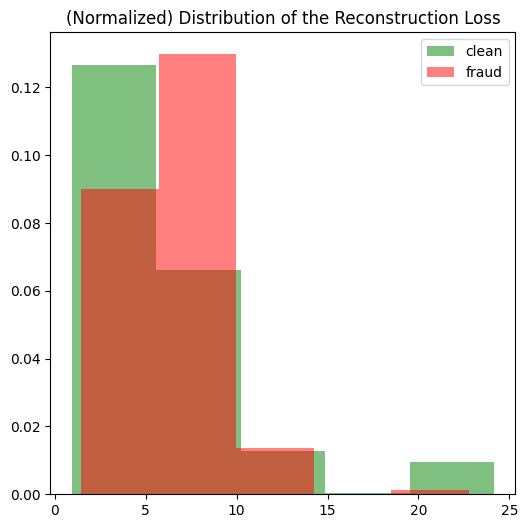

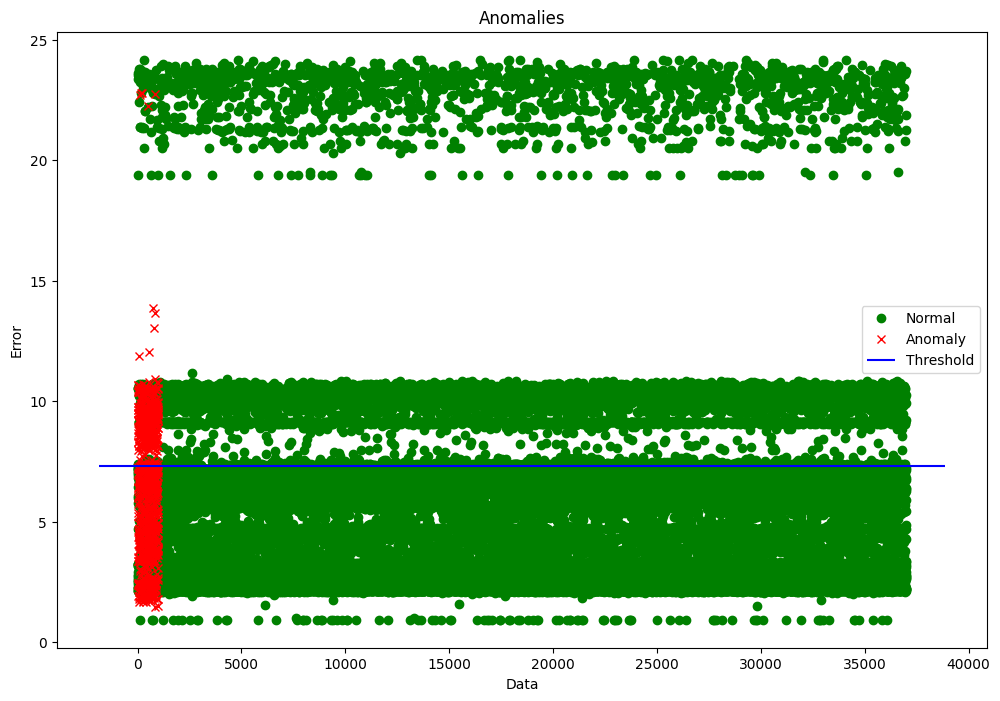

In [81]:
clean = distances[y_test==0]
fraud = distances[y_test==1]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(clean, bins=5, density=True, label="clean", alpha=.5, color="green")
ax.hist(fraud, bins=5, density=True, label="fraud", alpha=.5, color="red")

plt.title("(Normalized) Distribution of the Reconstruction Loss")
plt.legend()
plt.show()

figure, axes = plt.subplots(figsize=(12, 8))
axes.plot(clean, marker='o', linestyle='',
                    color='g', label="Normal")
axes.plot(fraud, marker='x', linestyle='',
                    color='r', label="Anomaly")

axes.hlines(threshold, axes.get_xlim()[0], axes.get_xlim()[1], colors="b", zorder=100, label='Threshold')
axes.legend()

plt.title("Anomalies")
plt.ylabel("Distance")
plt.xlabel("Data")
plt.show()

F1 Score: 0.09837209302325581
Precision: 0.05565789473684211
Recall: 0.423
Accuracy: 0.7959473684210526


Text(50.722222222222214, 0.5, 'True Label')

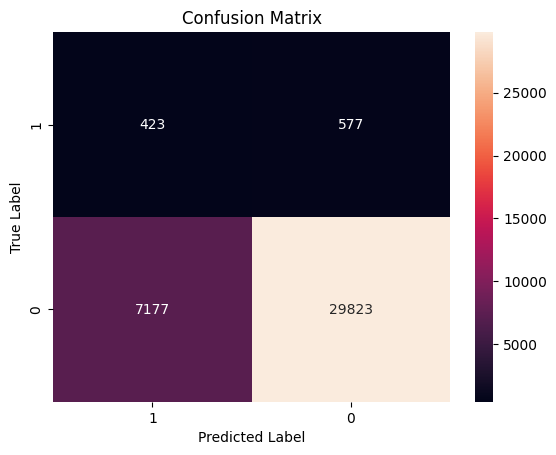

In [82]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

f1_test = f1_score(y_test, anomalies)
precision_test = precision_score(y_test, anomalies)
recall_test = recall_score(y_test, anomalies)
accuracy_test = accuracy_score(y_test, anomalies)

print(f"F1 Score: {f1_test}\nPrecision: {precision_test}\nRecall: {recall_test}\nAccuracy: {accuracy_test}")

cm = confusion_matrix(y_test, anomalies)
plt.title("Confusion Matrix")
ax = sns.heatmap(cm, annot=True, fmt='0.0f')
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

# Predictions using enitre anomaly detector

## Computing threshold for anomaly detection

In [83]:
reconstructions = autoencoder.predict(x_test_scaled)

mse = np.mean(np.power(x_test_scaled - reconstructions, 2), axis=1)

1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1s 939us/step


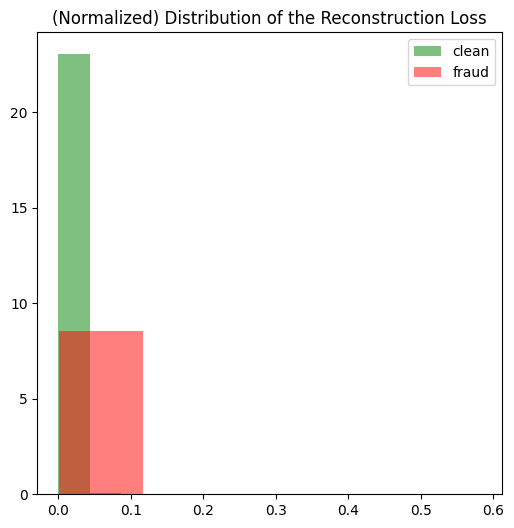

In [84]:
clean = mse[y_test==0]
fraud = mse[y_test==1]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(clean, bins=5, density=True, label="clean", alpha=.5, color="green")
ax.hist(fraud, bins=5, density=True, label="fraud", alpha=.5, color="red")

plt.title("(Normalized) Distribution of the Reconstruction Loss")
plt.legend()
plt.show()

In [85]:
def mad_score(points):
    """https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h.htm """
    m = np.median(points)
    ad = np.abs(points - m)
    mad = np.median(ad)
    
    return 0.6745 * ad / mad

In [86]:
THRESHOLD = 55
z_scores = mad_score(mse)

outliers = z_scores > THRESHOLD

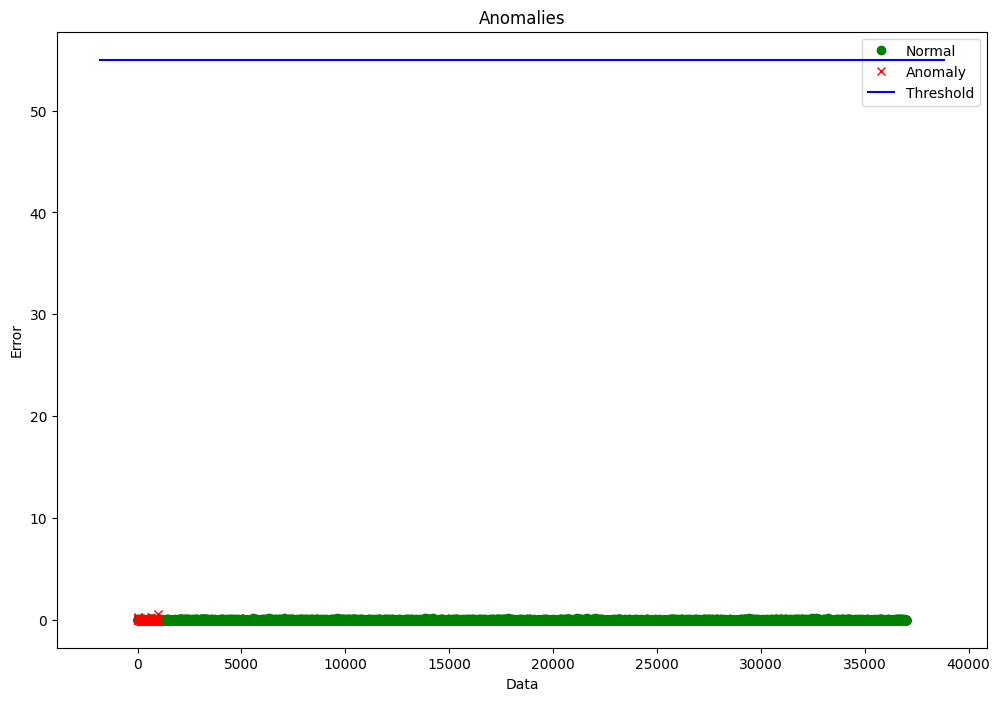

In [87]:
threshold = THRESHOLD
figure, axes = plt.subplots(figsize=(12, 8))
axes.plot(clean, marker='o', linestyle='',
                    color='g', label="Normal")
axes.plot(fraud, marker='x', linestyle='',
                    color='r', label="Anomaly")

axes.hlines(threshold, axes.get_xlim()[0], axes.get_xlim()[1], colors="b", zorder=100, label='Threshold')
axes.legend()

plt.title("Anomalies")
plt.ylabel("Error")
plt.xlabel("Data")
plt.show()

F1 Score: 0.11606391925988226
Precision: 0.36507936507936506
Recall: 0.069
Accuracy: 0.9723421052631579


Text(50.722222222222214, 0.5, 'True Label')

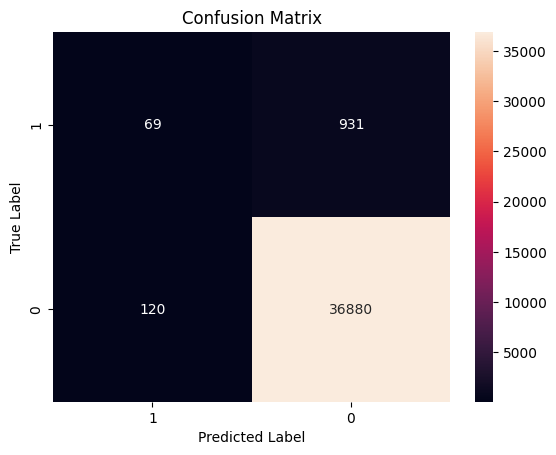

In [88]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

f1_test = f1_score(y_test, outliers)
precision_test = precision_score(y_test, outliers)
recall_test = recall_score(y_test, outliers)
accuracy_test = accuracy_score(y_test, outliers)

print(f"F1 Score: {f1_test}\nPrecision: {precision_test}\nRecall: {recall_test}\nAccuracy: {accuracy_test}")

cm = confusion_matrix(y_test, outliers)
plt.title("Confusion Matrix")
ax = sns.heatmap(cm, annot=True, fmt='0.0f')
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

In [89]:
tn, fp, fn, tp = cm.ravel()
print("False Negative Rate:", fn/(fn+tn))
print("False Positive Rate:", fp/(fp+tp))

False Negative Rate: 0.024622464362222634
False Positive Rate: 0.6349206349206349
